# Ejercicio 1

1. Cargue y visualice las imágenes `patron2.tif` y `patron.tif` (a esta última utilícela a escala de grises).

- Reflexione acerca de qué histograma espera obtener para cada una.
- Obtenga los histogramas y grafíquelos.

```py
histr = cv2.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])
pyplot.plot(histr)
```

- Identifique la información suministrada y analícela en relación a su expectativa.

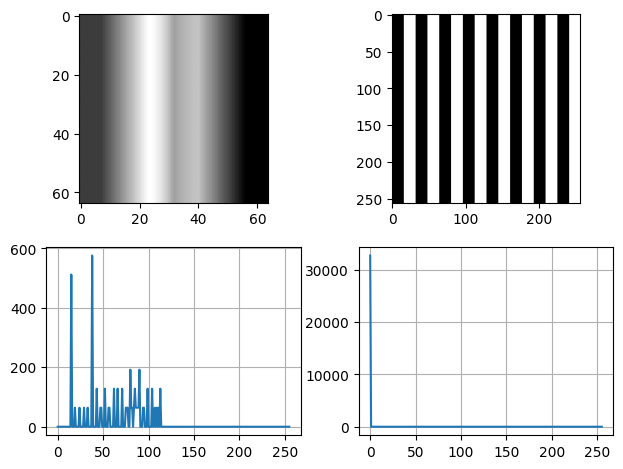

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("patron.tif", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("patron2.tif", cv2.IMREAD_GRAYSCALE)

histr1 = cv2.calcHist([img1], channels=[0], mask=None, histSize=[256], ranges=[0, 255])
histr2 = cv2.calcHist([img2], channels=[0], mask=None, histSize=[256], ranges=[0, 255])

fig, ax = plt.subplots(2, 2)
fig.tight_layout()

ax[0][0].imshow(img1, cmap='gray')
ax[0][1].imshow(img2, cmap='gray')
ax[1][0].grid()
ax[1][0].plot(histr1)
ax[1][1].grid()
ax[1][1].plot(histr2);

2. Los archivos `histo1.tif`, `histo2.tif`, `histo3.tif`, `histo4.tif` e `histo5.tif` contienen histogramas de imágenes con diferentes características. Se pide:

- Analizando solamente los archivos de histograma y realice una descripción de la imagen a la que corresponden (¿es clara u oscura?, ¿tiene buen contraste?, ¿el histograma me explica algo respecto de la ubicación de los grises?, etc.).
- Anote la correspondencia histograma-imagen con los archivos `imagenA.tif` a `imagenE.tif`, basándose en su análisis previo.
- Cargue las imágenes originales y muestre los histogramas. Comparelos con sus respuestas del punto anterior.
- Obtenga y analice la utilidad de las siguientes propiedades estadísticas de los histogramas: media, varianza, asimetría, energía y entropía.

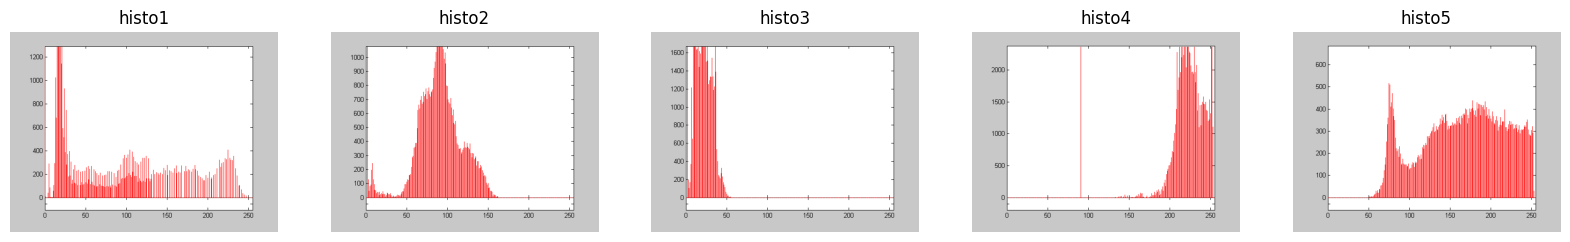

In [2]:
histrImg1 = cv2.imread('histo1.tif')
histrImg2 = cv2.imread('histo2.tif')
histrImg3 = cv2.imread('histo3.tif')
histrImg4 = cv2.imread('histo4.tif')
histrImg5 = cv2.imread('histo5.tif')

fig, ax = plt.subplots(1,5)
fig.set_figwidth(20)
fig.set_figheight(10)
ax[0].axis('off')
ax[0].set_title('histo1')
ax[0].imshow(histrImg1)
ax[1].axis('off')
ax[1].set_title('histo2')
ax[1].imshow(histrImg2)
ax[2].axis('off')
ax[2].set_title('histo3')
ax[2].imshow(histrImg3)
ax[3].axis('off')
ax[3].set_title('histo4')
ax[3].imshow(histrImg4)
ax[4].axis('off')
ax[4].set_title('histo5')
ax[4].imshow(histrImg5);

- `histo1`: mayormente oscura con buen contraste. Prediccion: `imagenA.tif`.
- `histo2`: oscura con poco contraste y sin claros. Prediccion: `imagenC.tif`.
- `histo3`: oscura sin contraste ni grises claros. Prediccion: `imagenE.tif`.
- `histo4`: brillante con poco contraste y grises de valor ~90 agregados artificialmente (ruido o un bloque agregado en la imagen). Prediccion: `imagenB.tif`.
- `histo5`: mayormente brillante con buen contraste y sin oscuros intensos. Prediccion: `imagenD.tif`.

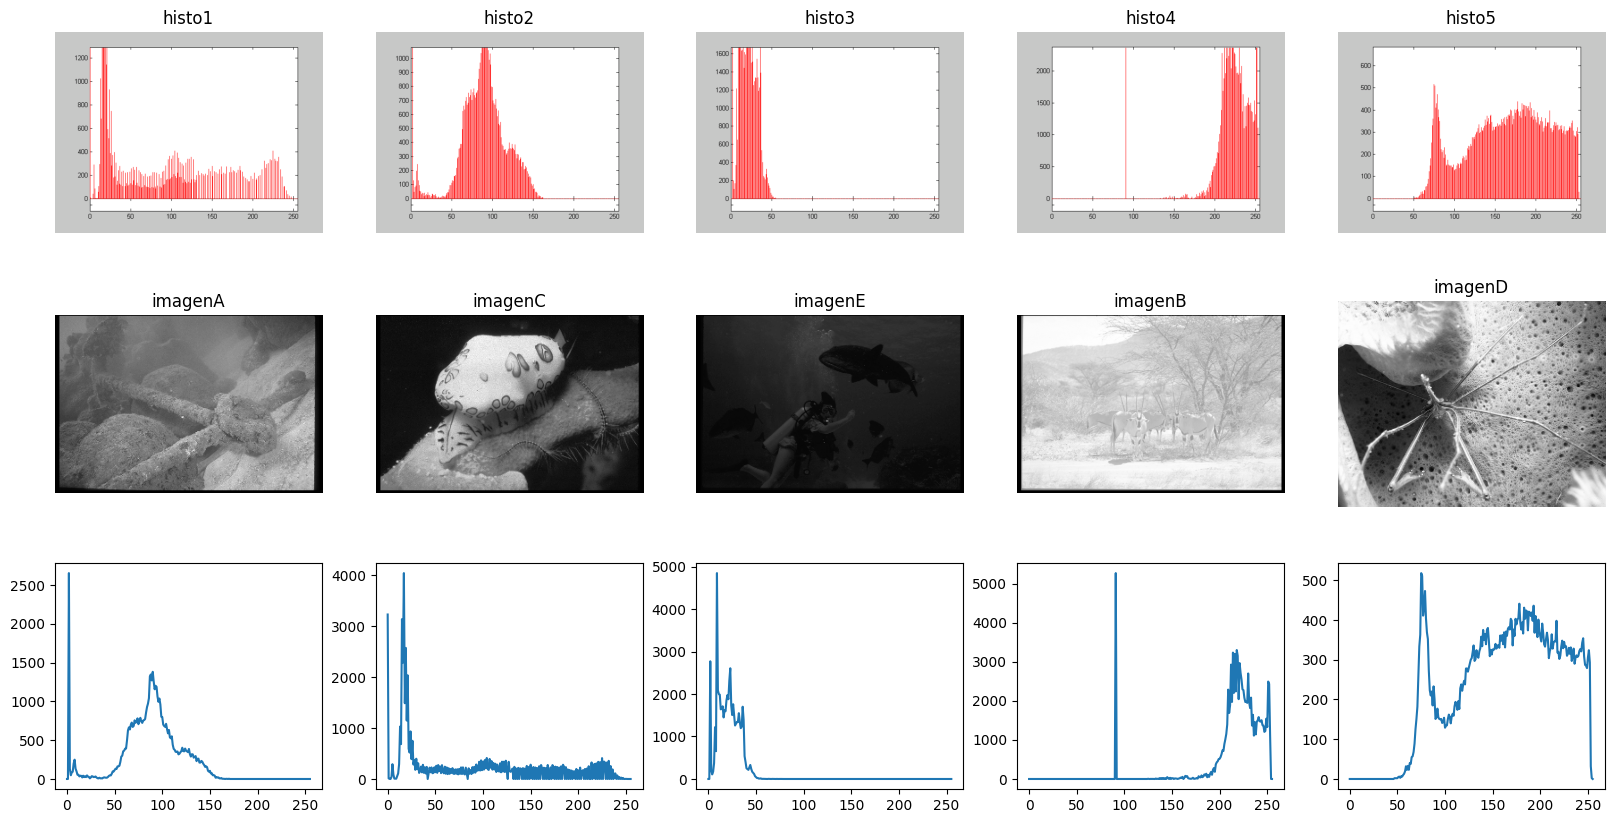

In [3]:
imagenA = cv2.imread('imagenA.tif', cv2.IMREAD_GRAYSCALE)
imagenB = cv2.imread('imagenB.tif', cv2.IMREAD_GRAYSCALE)
imagenC = cv2.imread('imagenC.tif', cv2.IMREAD_GRAYSCALE)
imagenD = cv2.imread('imagenD.tif', cv2.IMREAD_GRAYSCALE)
imagenE = cv2.imread('imagenE.tif', cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(3,5)
fig.set_figwidth(20)
fig.set_figheight(10)
ax[0][0].axis('off')
ax[0][0].set_title('histo1')
ax[0][0].imshow(histrImg1)
ax[0][1].axis('off')
ax[0][1].set_title('histo2')
ax[0][1].imshow(histrImg2)
ax[0][2].axis('off')
ax[0][2].set_title('histo3')
ax[0][2].imshow(histrImg3)
ax[0][3].axis('off')
ax[0][3].set_title('histo4')
ax[0][3].imshow(histrImg4)
ax[0][4].axis('off')
ax[0][4].set_title('histo5')
ax[0][4].imshow(histrImg5)

ax[1][0].axis('off')
ax[1][0].set_title('imagenA')
ax[1][0].imshow(imagenA, cmap='gray')
ax[1][1].axis('off')
ax[1][1].set_title('imagenC')
ax[1][1].imshow(imagenC, cmap='gray')
ax[1][2].axis('off')
ax[1][2].set_title('imagenE')
ax[1][2].imshow(imagenE, cmap='gray')
ax[1][3].axis('off')
ax[1][3].set_title('imagenB')
ax[1][3].imshow(imagenB, cmap='gray')
ax[1][4].axis('off')
ax[1][4].set_title('imagenD')
ax[1][4].imshow(imagenD, cmap='gray')

ax[2][0].plot(cv2.calcHist([imagenA], [0], None, [256], [0, 255]))
ax[2][1].plot(cv2.calcHist([imagenC], [0], None, [256], [0, 255]))
ax[2][2].plot(cv2.calcHist([imagenE], [0], None, [256], [0, 255]))
ax[2][3].plot(cv2.calcHist([imagenB], [0], None, [256], [0, 255]))
ax[2][4].plot(cv2.calcHist([imagenD], [0], None, [256], [0, 255]));

3. Cargue una imagen y realice la ecualización de su histograma. `img_equ = cv2.equalizeHist(img)`

- Muestre en una misma ventana la imagen original, la versión ecualizada y sus respectivos histogramas.
- Estudie la información suministrada por los histogramas. ¿Qué diferencias nota respecto a las definiciones teóricas?
- Repita el análisis para distintas imágenes

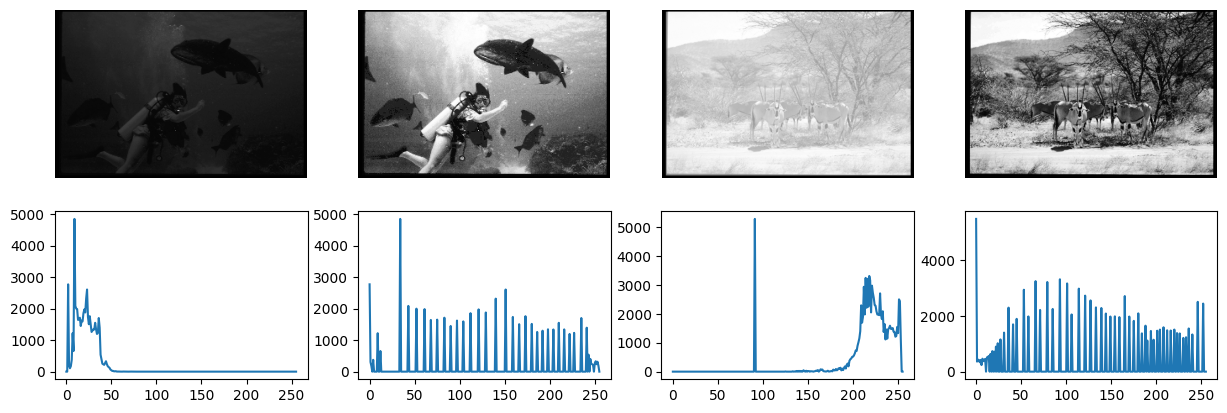

In [4]:
equ_imagenE = cv2.equalizeHist(imagenE)
equ_imagenB = cv2.equalizeHist(imagenB)

fig, ax = plt.subplots(2,4)
fig.set_figwidth(15)

ax[0][0].axis('off')
ax[0][0].imshow(imagenE, cmap='gray')
ax[0][1].axis('off')
ax[0][1].imshow(equ_imagenE, cmap='gray')
ax[0][2].axis('off')
ax[0][2].imshow(imagenB, cmap='gray')
ax[0][3].axis('off')
ax[0][3].imshow(equ_imagenB, cmap='gray')
ax[1][0].plot(cv2.calcHist([imagenE], [0], None, [256], [0, 255]))
ax[1][1].plot(cv2.calcHist([equ_imagenE], [0], None, [256], [0, 255]));
ax[1][2].plot(cv2.calcHist([imagenB], [0], None, [256], [0, 255]));
ax[1][3].plot(cv2.calcHist([equ_imagenB], [0], None, [256], [0, 255]));

4. (Opcional): Investigue la ecualización adaptativa de histogramas CLAHE (Contrast Limited Adaptive Histogram Equalization)

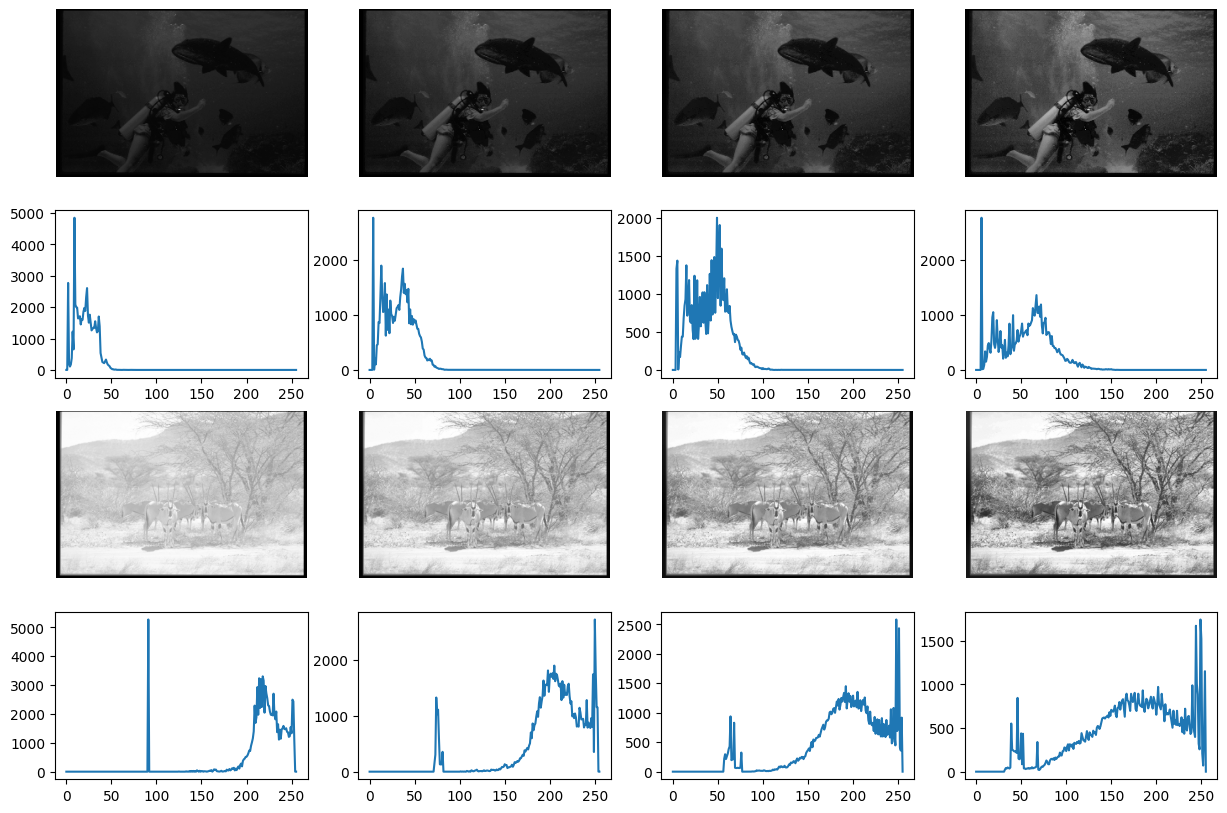

In [5]:
clahe1 = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(4,4))
clahe2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))
clahe3 = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4,4))

clahe1_imagenE = clahe1.apply(imagenE)
clahe2_imagenE = clahe2.apply(imagenE)
clahe3_imagenE = clahe3.apply(imagenE)

clahe1_imagenB = clahe1.apply(imagenB)
clahe2_imagenB = clahe2.apply(imagenB)
clahe3_imagenB = clahe3.apply(imagenB)

fig, ax = plt.subplots(4,4)
fig.set_figwidth(15)
fig.set_figheight(10)

ax[0][0].axis('off')
ax[0][0].imshow(imagenE, cmap='gray')
ax[0][1].axis('off')
ax[0][1].imshow(clahe1_imagenE, cmap='gray')
ax[0][2].axis('off')
ax[0][2].imshow(clahe2_imagenE, cmap='gray')
ax[0][3].axis('off')
ax[0][3].imshow(clahe3_imagenE, cmap='gray')
ax[1][0].plot(cv2.calcHist([imagenE], [0], None, [256], [0, 255]))
ax[1][1].plot(cv2.calcHist([clahe1_imagenE], [0], None, [256], [0, 255]));
ax[1][2].plot(cv2.calcHist([clahe2_imagenE], [0], None, [256], [0, 255]));
ax[1][3].plot(cv2.calcHist([clahe3_imagenE], [0], None, [256], [0, 255]));

ax[2][0].axis('off')
ax[2][0].imshow(imagenB, cmap='gray')
ax[2][1].axis('off')
ax[2][1].imshow(clahe1_imagenB, cmap='gray')
ax[2][2].axis('off')
ax[2][2].imshow(clahe2_imagenB, cmap='gray')
ax[2][3].axis('off')
ax[2][3].imshow(clahe3_imagenB, cmap='gray')
ax[3][0].plot(cv2.calcHist([imagenB], [0], None, [256], [0, 255]))
ax[3][1].plot(cv2.calcHist([clahe1_imagenB], [0], None, [256], [0, 255]));
ax[3][2].plot(cv2.calcHist([clahe2_imagenB], [0], None, [256], [0, 255]));
ax[3][3].plot(cv2.calcHist([clahe3_imagenB], [0], None, [256], [0, 255]));